# 🍽️ Zomato Data Analysis
Exploratory Data Analysis (EDA) of Zomato dataset to uncover insights about restaurant types, ratings, costs, and online ordering trends.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Step 2: Load the Dataset
We now load the Zomato dataset and display the first few rows.


In [2]:
dataframe = pd.read_csv("Zomato-data-.csv")
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


 Observation: The dataset contains columns such as Restaurant Name, Location, Rating, Votes, Cost, and Online Order availability.


## Step 3: Data Cleaning and Preparation
Before moving further we need to clean and process the data.

1. Convert the rate column to a float by removing denominator characters
2. Getting summary of the dataframe use df.info().
3. Checking for missing or null values to identify any data gaps.

In [3]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0];
    return float(value )

dataframe['rate'] = dataframe['rate'].apply(handleRate) 
print(dataframe.head())

dataframe.info()

print(dataframe.isnull().sum())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148

## Step 4: Exploring Restaurant Types
1. The listed_in (type) column to identify popular restaurant categories.
2. Votes by Restaurant Type
Here we get the count of votes for each category.


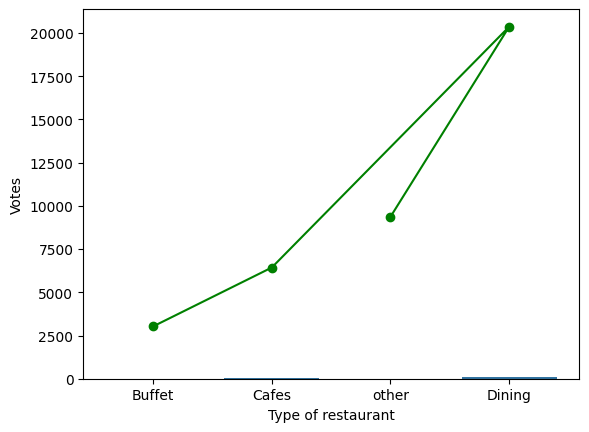

In [4]:
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("Type of restaurant")

grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')
plt.show()

## Step 5: Identify the Most Voted Restaurant
Find the restaurant with the highest number of votes.

In [5]:
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)


Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


## Step 6: Online Order Availabiliy
the online_order column to see how many restaurants accept online orders.

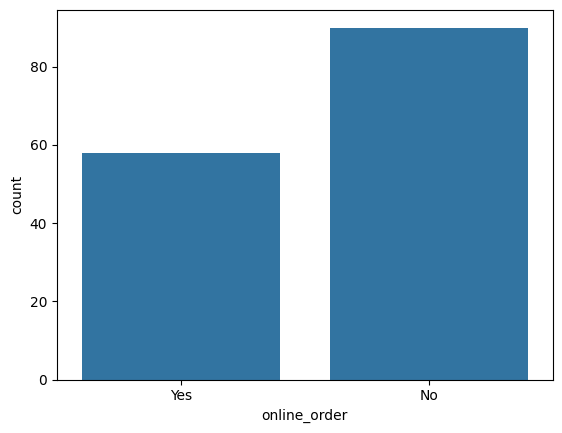

In [6]:
sns.countplot(x=dataframe['online_order'])
plt.show()

## Step 7: Analyze Ratings
Checking the distribution of ratings from the rate column.

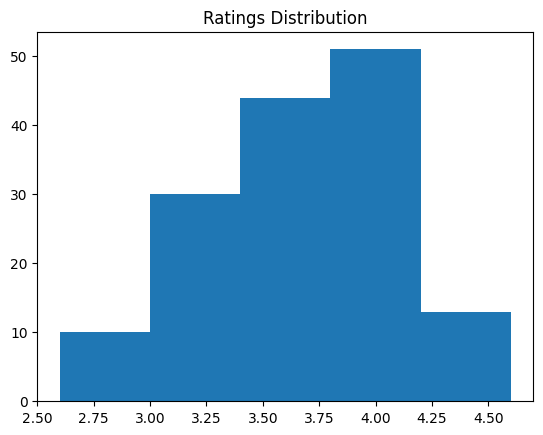

In [7]:
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

## Step 8: Approximate Cost for Couples
Analyze the approx_cost(for two people) column to find the preferred price range.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

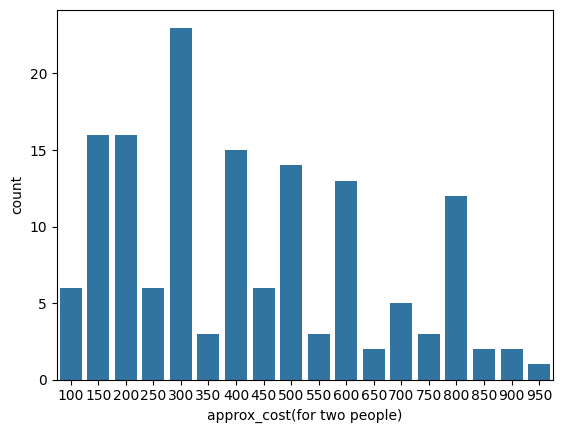

In [8]:
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

## Step 9: Ratings Comparison - Online vs Offline Orders
Compare ratings between restaurants that accept online orders and those that don't.

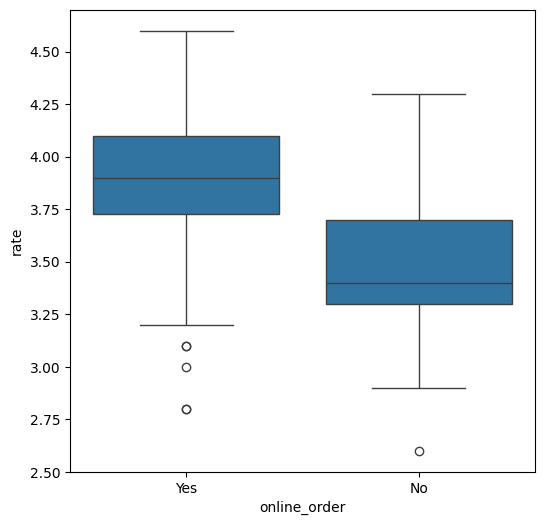

In [9]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)
plt.show()

## Step 10: Order Mode Preferences by Restaurant Type
Find the relationship between order mode (online_order) and restaurant type (listed_in(type)).

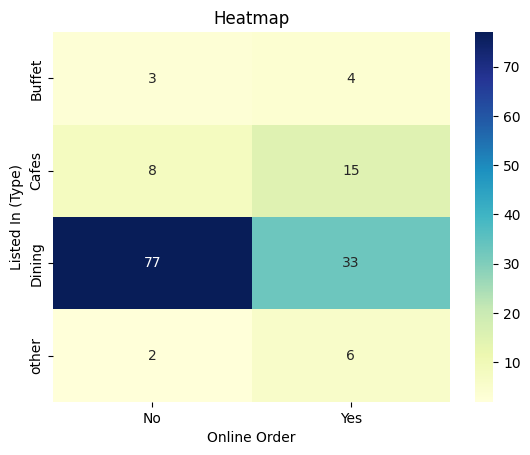

In [10]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()